In [1]:
# ==============================
# Decision Tree Regressor Example
# ==============================

# Import libraries
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
# =====================================
# Step 1: Load California Housing Dataset
# =====================================

housing = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Add target column
df['Price'] = housing.target

In [3]:
# =====================================
# Step 2: View Dataset
# =====================================

print("First 5 Rows:\n")
df.head()

First 5 Rows:



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# =====================================
# Step 3: Features and Target
# =====================================

X = df.drop('Price', axis=1)
y = df['Price']

In [5]:
# =====================================
# Step 4: Split Dataset
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


In [6]:
# =====================================
# Step 5: Create Decision Tree Regressor
# =====================================

model = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=5,
    random_state=42
)

In [7]:
# =====================================
# Step 6: Train Model
# =====================================

model.fit(X_train, y_train)

# =====================================
# Step 7: Make Predictions
# =====================================

y_pred = model.predict(X_test)

In [8]:
# =====================================
# Step 8: Evaluate Model
# =====================================

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("------------------")
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


Model Evaluation:
------------------
Mean Squared Error: 0.5245146178314735
Mean Absolute Error: 0.5222592972077786
R2 Score: 0.5997321244428706


In [9]:
# =====================================
# Step 9: Compare Actual vs Predicted
# =====================================

results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print("\nActual vs Predicted:\n")
print(results.head(10))


Actual vs Predicted:

   Actual Price  Predicted Price
0       0.47700         1.168573
1       0.45800         1.271581
2       5.00001         3.199582
3       2.18600         2.204763
4       2.78000         1.642797
5       1.58700         2.337900
6       1.98200         1.920621
7       1.57500         1.642797
8       3.40000         2.375496
9       4.46600         4.778789


In [10]:
# =====================================
# Step 10: Feature Importance
# =====================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:\n")
print(importance)


Feature Importance:

      Feature  Importance
0      MedInc    0.771212
5    AveOccup    0.128407
1    HouseAge    0.041621
2    AveRooms    0.031261
6    Latitude    0.022049
4  Population    0.002485
7   Longitude    0.002097
3   AveBedrms    0.000869


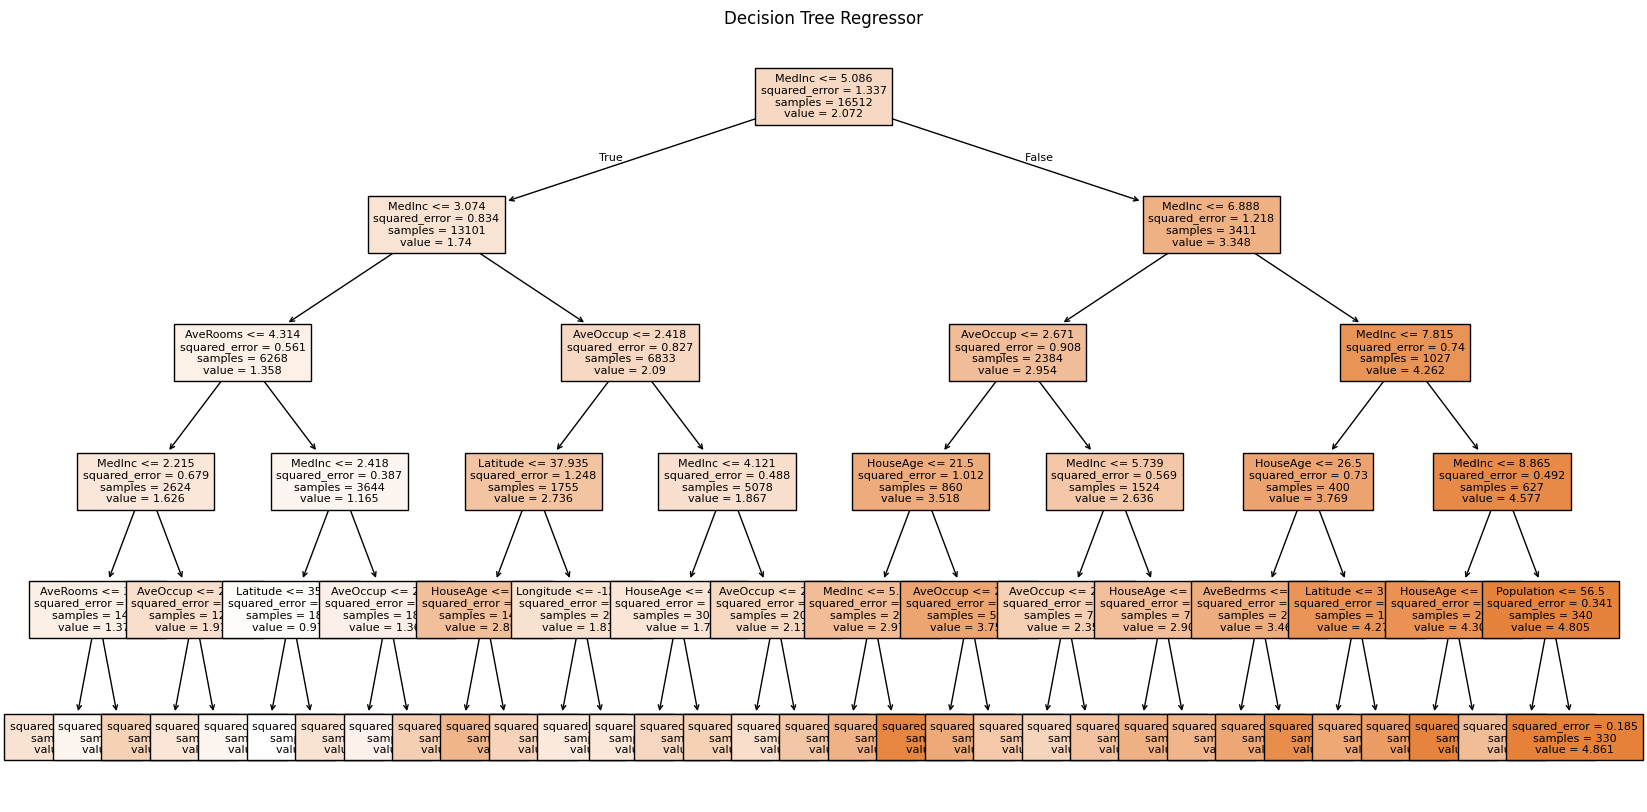

In [11]:
# =====================================
# Step 11: Visualize Decision Tree
# =====================================

import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(20,10))

tree.plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    fontsize=8
)

plt.title("Decision Tree Regressor")

plt.show()